In [11]:
import pandas as pd

In [64]:
df_ai_jobs = pd.read_csv("ai_jobs_market_2025_2026.csv")
print("*** ai_jobs_market_2025_2026.csv ***")
print("\nFirst 5 rows:")
print(df_ai_jobs.head())
print("DataFrame Info:")
df_ai_jobs.info()
print("\n")


*** ai_jobs_market_2025_2026.csv ***

First 5 rows:
      job_id           job_title      job_category  experience_level  \
0  AIJOB0001  AI Agent Developer    AI Engineering  Senior (6-9 yrs)   
1  AIJOB0002     Prompt Engineer    AI Engineering  Senior (6-9 yrs)   
2  AIJOB0003        LLM Engineer    AI Engineering  Senior (6-9 yrs)   
3  AIJOB0004  Data Engineer (AI)  Data Engineering  Senior (6-9 yrs)   
4  AIJOB0005  AI Product Manager           Product    Lead (10+ yrs)   

   years_of_experience    education_required  annual_salary_usd  \
0                    7              Master's           239000.0   
1                    2            Bachelor's           166000.0   
2                    4           Associate's           360000.0   
3                    3            Bachelor's           161000.0   
4                    5  Bootcamp/Self-taught           283000.0   

   salary_min_usd  salary_max_usd         city  ... ai_salary_premium_pct  \
0          155000          290000  

In [13]:
df_bmw_sales = pd.read_csv("bmw_global_sales_2018_2025.csv")
print('*** bmw_global_sales_2018_2025.csv ***')
print('First 5 rows:')
print(df_bmw_sales.head())
print('\nDataFrame Info:')
df_bmw_sales.info()
print('\n')

*** bmw_global_sales_2018_2025.csv ***
First 5 rows:
   Year  Month  Region     Model  Units_Sold  Avg_Price_EUR  Revenue_EUR  \
0  2018      1  Europe  3 Series        7822          47482    371404204   
1  2018      1  Europe  5 Series       10280          61685    634121800   
2  2018      1  Europe        X3        3105          58433    181434465   
3  2018      1  Europe        X5        7420          67955    504226100   
4  2018      1  Europe        X7        8474          92300    782150200   

   BEV_Share  Premium_Share  GDP_Growth  Fuel_Price_Index  
0      0.011          19.12         3.5               1.0  
1      0.019          19.12         3.5               1.0  
2      0.022          19.12         3.5               1.0  
3      0.021          19.12         3.5               1.0  
4      0.035          19.12         3.5               1.0  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   C

In [65]:
def generate_data_profile(df, df_name):
    print(f"\n--- Data Profile for {df_name} ---")
    profile = []
    for col in df.columns:
        col_dtype = df[col].dtype
        unique_count = df[col].nunique()
        missing_count = df[col].isnull().sum()
        profile.append({
            'Column': col,
            'Data Type': col_dtype,
            'Unique Values': unique_count,
            'Missing Values': missing_count
        })
    profile_df = pd.DataFrame(profile)
    print(profile_df.to_string())
    print("------------------------------------")

In [67]:
generate_data_profile(df_ai_jobs, 'df_ai_jobs')
generate_data_profile(df_bmw_sales, 'df_bmw_sales')


--- Data Profile for df_ai_jobs ---
                   Column Data Type  Unique Values  Missing Values
0                  job_id    object           1500               0
1               job_title    object             25               0
2            job_category    object             12               0
3        experience_level    object              4               0
4     years_of_experience     int64             15               0
5      education_required    object              5               0
6       annual_salary_usd   float64            248               0
7          salary_min_usd     int64             17               0
8          salary_max_usd     int64             16               0
9                    city    object             20               0
10                country    object             14               0
11            remote_work    object              3               0
12           company_size    object              5               0
13               industry

In [68]:
suitability_data = [
    {
        'Dataset': 'df_ai_jobs',
        'Algorithm Type': 'Regression',
        'Suitability': 'Highly Suitable',
        'Rationale': 'Predicting `annual_salary_usd` based on numerical features (e.g., years_of_experience) and categorical features (e.g., job_category, education_required).'
    },
    {
        'Dataset': 'df_ai_jobs',
        'Algorithm Type': 'Classification',
        'Suitability': 'Highly Suitable',
        'Rationale': 'Predicting categorical outcomes like `job_category`, `experience_level`, `education_required`, `is_senior`, `is_remote_friendly`, `is_llm_role`, or `salary_tier`.'
    },
    {
        'Dataset': 'df_ai_jobs',
        'Algorithm Type': 'Clustering',
        'Suitability': 'Suitable',
        'Rationale': 'Grouping similar jobs or companies based on characteristics like `job_category`, `required_skills`, `city`, `company_size`, and `industry`.'
    },
    {
        'Dataset': 'df_ai_jobs',
        'Algorithm Type': 'Natural Language Processing (NLP)',
        'Suitability': 'Highly Suitable',
        'Rationale': 'Text fields like `job_title` and `required_skills` are ideal for text analysis, topic modeling, or sentiment analysis related to job descriptions.'
    },

    {
        'Dataset': 'df_bmw_sales',
        'Algorithm Type': 'Time Series Analysis',
        'Suitability': 'Highly Suitable',
        'Rationale': 'Features like `Units_Sold`, `Avg_Price_EUR`, `Revenue_EUR`, `BEV_Share`, `Premium_Share`, `GDP_Growth`, and `Fuel_Price_Index` are recorded monthly over several years, making it ideal for forecasting and trend analysis.'
    },
    {
        'Dataset': 'df_bmw_sales',
        'Algorithm Type': 'Regression',
        'Suitability': 'Highly Suitable',
        'Rationale': 'Predicting `Units_Sold`, `Avg_Price_EUR`, or `Revenue_EUR` based on time, region, model, GDP growth, and fuel prices.'
    },
    {
        'Dataset': 'df_bmw_sales',
        'Algorithm Type': 'Clustering',
        'Suitability': 'Suitable',
        'Rationale': 'Segmenting regions or models based on sales performance, pricing trends, or market share characteristics.'
    }
]

In [69]:
df_suitability = pd.DataFrame(suitability_data)
print(df_suitability.to_string())

        Dataset                     Algorithm Type      Suitability                                                                                                                                                                                                                    Rationale
0    df_ai_jobs                         Regression  Highly Suitable                                                                    Predicting `annual_salary_usd` based on numerical features (e.g., years_of_experience) and categorical features (e.g., job_category, education_required).
1    df_ai_jobs                     Classification  Highly Suitable                                                           Predicting categorical outcomes like `job_category`, `experience_level`, `education_required`, `is_senior`, `is_remote_friendly`, `is_llm_role`, or `salary_tier`.
2    df_ai_jobs                         Clustering         Suitable                                                                  

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
suitability_mapping = {
    'Highly Suitable': 3,
    'Suitable': 2,
    'Challenging': 1
}

In [72]:
print("Added 'Suitability_Score' column to df_suitability.")
print("First 5 rows of df_suitability with new score:")
print(df_suitability.head())

Added 'Suitability_Score' column to df_suitability.
First 5 rows of df_suitability with new score:
        Dataset                     Algorithm Type      Suitability  \
0    df_ai_jobs                         Regression  Highly Suitable   
1    df_ai_jobs                     Classification  Highly Suitable   
2    df_ai_jobs                         Clustering         Suitable   
3    df_ai_jobs  Natural Language Processing (NLP)  Highly Suitable   
4  df_bmw_sales               Time Series Analysis  Highly Suitable   

                                           Rationale  
0  Predicting `annual_salary_usd` based on numeri...  
1  Predicting categorical outcomes like `job_cate...  
2  Grouping similar jobs or companies based on ch...  
3  Text fields like `job_title` and `required_ski...  
4  Features like `Units_Sold`, `Avg_Price_EUR`, `...  


In [73]:
unique_algorithm_types = df_suitability['Algorithm Type'].unique()

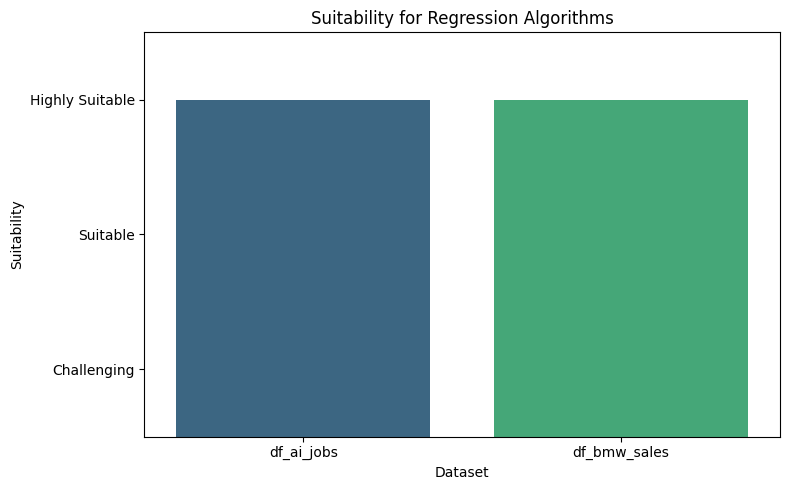

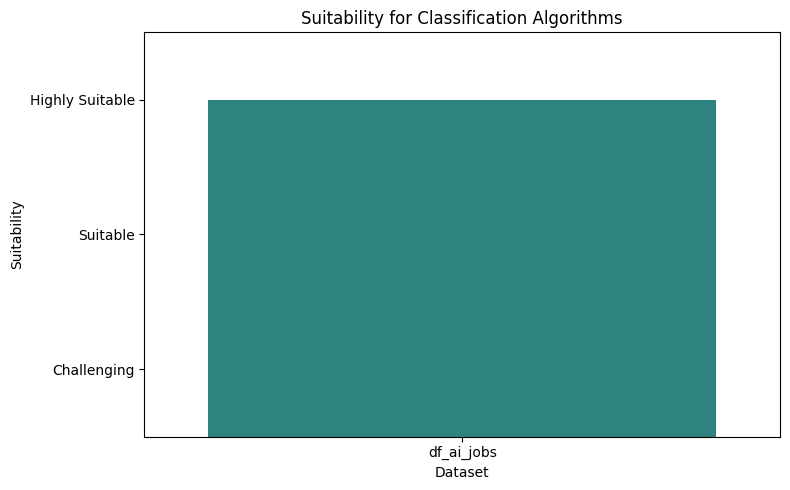

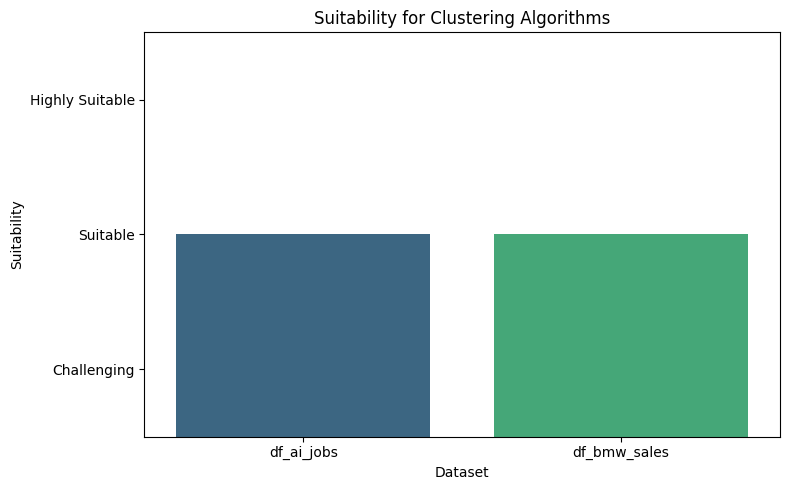

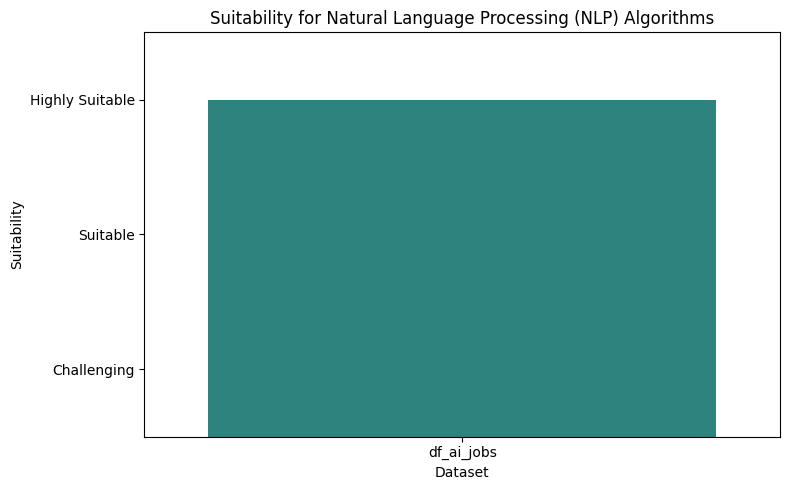

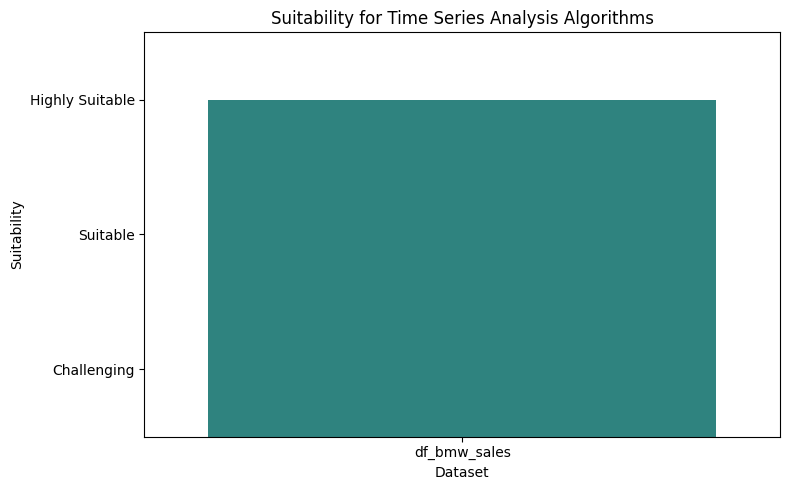

In [78]:
df_suitability['Suitability_Score'] = df_suitability['Suitability'].map(suitability_mapping)
inverse_suitability_mapping = {v: k for k, v in suitability_mapping.items()}
unique_algorithm_types = df_suitability['Algorithm Type'].unique()

for algorithm_type in unique_algorithm_types:
    plt.figure(figsize=(8, 5))
    filtered_df = df_suitability[df_suitability['Algorithm Type'] == algorithm_type]
    sns.barplot(x='Dataset', y='Suitability_Score', hue='Dataset', data=filtered_df, palette='viridis', legend=False)

    plt.yticks([1, 2, 3], [inverse_suitability_mapping[1], inverse_suitability_mapping[2], inverse_suitability_mapping[3]])

    plt.title(f'Suitability for {algorithm_type} Algorithms')
    plt.xlabel('Dataset')
    plt.ylabel('Suitability')
    plt.ylim(0.5, 3.5)
    plt.tight_layout()
    plt.show()

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

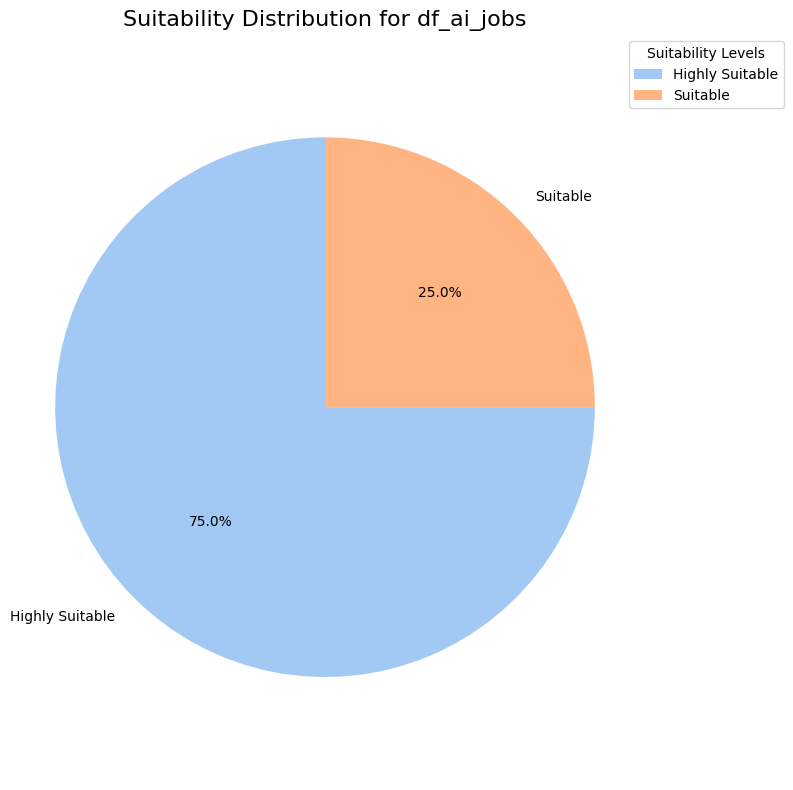

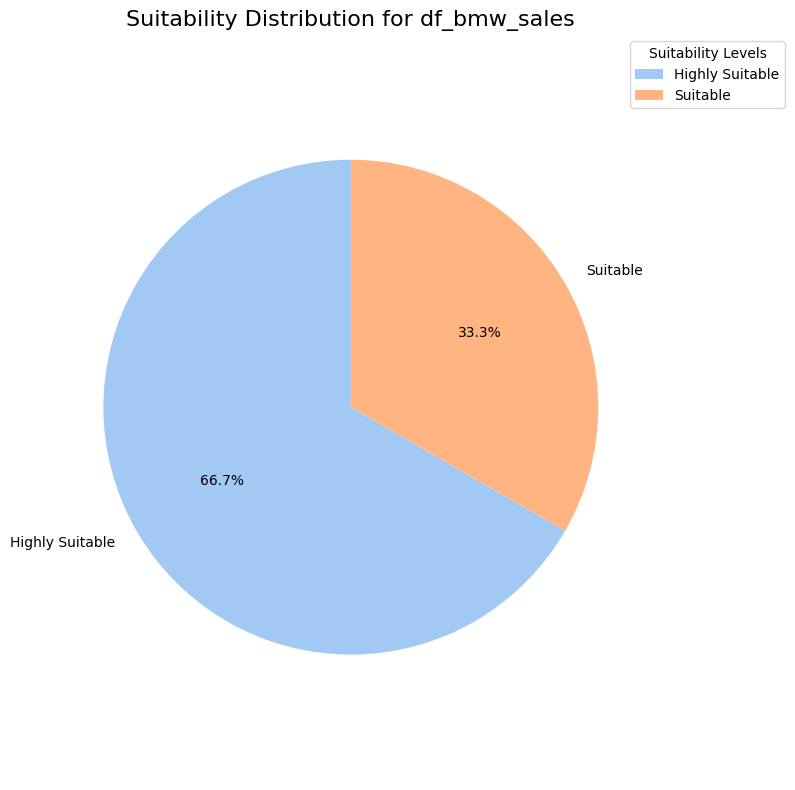

In [76]:
unique_datasets = df_suitability['Dataset'].unique()
for dataset_name in unique_datasets:
    plt.figure(figsize=(8, 8))
    filtered_df = df_suitability[df_suitability['Dataset'] == dataset_name]
    suitability_counts = filtered_df['Suitability'].value_counts()
    ordered_suitability_levels = ['Highly Suitable', 'Suitable', 'Challenging']
    suitability_counts = suitability_counts.reindex(ordered_suitability_levels, fill_value=0)

    labels = suitability_counts[suitability_counts > 0].index
    values = suitability_counts[suitability_counts > 0].values

    plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
    plt.title(f'Suitability Distribution for {dataset_name}', fontsize=16)
    plt.axis('equal')
    plt.legend(title='Suitability Levels', loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()